In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load all 3 COVID datasets
covid = pd.read_csv("covid_19_india.csv")
vaccine = pd.read_csv("covid_vaccine_statewise.csv")
tested = pd.read_csv("StatewiseTestingDetails.csv")

print("COVID Cases shape :", covid.shape)
print("Vaccine shape :", vaccine.shape)
print("Testing shape :", tested.shape)
print("All 3 files loaded successfully!")

COVID Cases shape : (18110, 9)
Vaccine shape : (7845, 24)
Testing shape : (16336, 5)
All 3 files loaded successfully!


In [4]:
print("=== COVID CASES — First 3 rows ===")
print(covid.head(3))
print()
print("Columns:", covid.columns.tolist())
print()
print("Missing values:")
print(covid.isnull().sum())

=== COVID CASES — First 3 rows ===
   Sno        Date     Time State/UnionTerritory ConfirmedIndianNational  \
0    1  2020-01-30  6:00 PM               Kerala                       1   
1    2  2020-01-31  6:00 PM               Kerala                       1   
2    3  2020-02-01  6:00 PM               Kerala                       2   

  ConfirmedForeignNational  Cured  Deaths  Confirmed  
0                        0      0       0          1  
1                        0      0       0          1  
2                        0      0       0          2  

Columns: ['Sno', 'Date', 'Time', 'State/UnionTerritory', 'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured', 'Deaths', 'Confirmed']

Missing values:
Sno                         0
Date                        0
Time                        0
State/UnionTerritory        0
ConfirmedIndianNational     0
ConfirmedForeignNational    0
Cured                       0
Deaths                      0
Confirmed                   0
dtype: i

In [3]:
print("=== VACCINE DATA — First 3 rows ===")
print(vaccine.head(3))
print("Columns:", vaccine.columns.tolist())
print()
print("=== TESTING DATA — First 3 rows ===")
print(tested.head(3))
print("Columns:", tested.columns.tolist())

=== VACCINE DATA — First 3 rows ===
   Updated On  State  Total Doses Administered  Sessions   Sites   \
0  16/01/2021  India                   48276.0    3455.0   2957.0   
1  17/01/2021  India                   58604.0    8532.0   4954.0   
2  18/01/2021  India                   99449.0   13611.0   6583.0   

   First Dose Administered  Second Dose Administered  \
0                  48276.0                       0.0   
1                  58604.0                       0.0   
2                  99449.0                       0.0   

   Male (Doses Administered)  Female (Doses Administered)  \
0                        NaN                          NaN   
1                        NaN                          NaN   
2                        NaN                          NaN   

   Transgender (Doses Administered)  ...  18-44 Years (Doses Administered)  \
0                               NaN  ...                               NaN   
1                               NaN  ...                     

### Which state has the most confirmed cases?


In [5]:
# Get latest record per state (maximum value = total)
state_cases = covid.groupby("State/UnionTerritory")["Confirmed"].max()
state_cases = state_cases.sort_values(ascending=False).head(10)

print("Top 10 states by confirmed cases:")
print(state_cases)

Top 10 states by confirmed cases:
State/UnionTerritory
Maharashtra       6363442
Maharashtra***    6229596
Kerala            3586693
Karnataka         2921049
Karanataka        2885238
Tamil Nadu        2579130
Andhra Pradesh    1985182
Uttar Pradesh     1708812
West Bengal       1534999
Delhi             1436852
Name: Confirmed, dtype: int64


### Insight
The analysis identifies the top 10 states with the highest confirmed COVID-19 cases based on their peak values. This suggests that these states experienced the most severe impact during the pandemic and may have required greater healthcare resources and policy attention.
Maharashtra has the highest number of confirmed cases, followed by Kerala and Karnataka...

## What is India total deaths and recovery?

In [6]:
total_confirmed = covid["Confirmed"].max()
total_deaths = covid["Deaths"].max()
total_cured = covid["Cured"].max()

death_rate = round((total_deaths / total_confirmed * 100), 2)
recovery_rate = round((total_cured / total_confirmed * 100), 2)

print(f"Total Confirmed : {total_confirmed:,}")
print(f"Total Deaths : {total_deaths:,}")
print(f"Total Recovered : {total_cured:,}")
print(f"Death Rate : {death_rate}%")
print(f"Recovery Rate : {recovery_rate}%")

Total Confirmed : 6,363,442
Total Deaths : 134,201
Total Recovered : 6,159,676
Death Rate : 2.11%
Recovery Rate : 96.8%


### Insight 
The total confirmed cases are 6.36 million, with a death rate of 2.11% and a recovery rate of 96.8%. The significantly higher recovery rate compared to the death rate indicates effective healthcare response and a high probability of patient recovery during the pandemic.

## Top 5 vaccinated states

In [7]:
# Check column names first
print("Vaccine columns:", vaccine.columns.tolist())

# Use the correct column name from your file
# Common names: 'Total Doses Administered' or 'Total Doses'
vax_col = [c for c in vaccine.columns if 'dose' in c.lower() or 'total' in c.lower()]
print("Dose columns found:", vax_col)

# Use first match
if vax_col:
    col = vax_col[0]
    top_vax = vaccine[vaccine["State"] != "India"].groupby("State")[col].max().sort_values(ascending=False).head(5)
    print(f"\nTop 5 states by {col}:")
    print(top_vax)

Vaccine columns: ['Updated On', 'State', 'Total Doses Administered', 'Sessions', ' Sites ', 'First Dose Administered', 'Second Dose Administered', 'Male (Doses Administered)', 'Female (Doses Administered)', 'Transgender (Doses Administered)', ' Covaxin (Doses Administered)', 'CoviShield (Doses Administered)', 'Sputnik V (Doses Administered)', 'AEFI', '18-44 Years (Doses Administered)', '45-60 Years (Doses Administered)', '60+ Years (Doses Administered)', '18-44 Years(Individuals Vaccinated)', '45-60 Years(Individuals Vaccinated)', '60+ Years(Individuals Vaccinated)', 'Male(Individuals Vaccinated)', 'Female(Individuals Vaccinated)', 'Transgender(Individuals Vaccinated)', 'Total Individuals Vaccinated']
Dose columns found: ['Total Doses Administered', 'First Dose Administered', 'Second Dose Administered', 'Male (Doses Administered)', 'Female (Doses Administered)', 'Transgender (Doses Administered)', ' Covaxin (Doses Administered)', 'CoviShield (Doses Administered)', 'Sputnik V (Doses Adm

## Insight
After removing the aggregate value "India," Utter Pradesh has the highest number of vaccine doses administered, followed by Maharashtra and Gujarat. This indicates that these states have achieved higher vaccination coverage compared to others.

## Top 10 states by cases(horizontal bar)

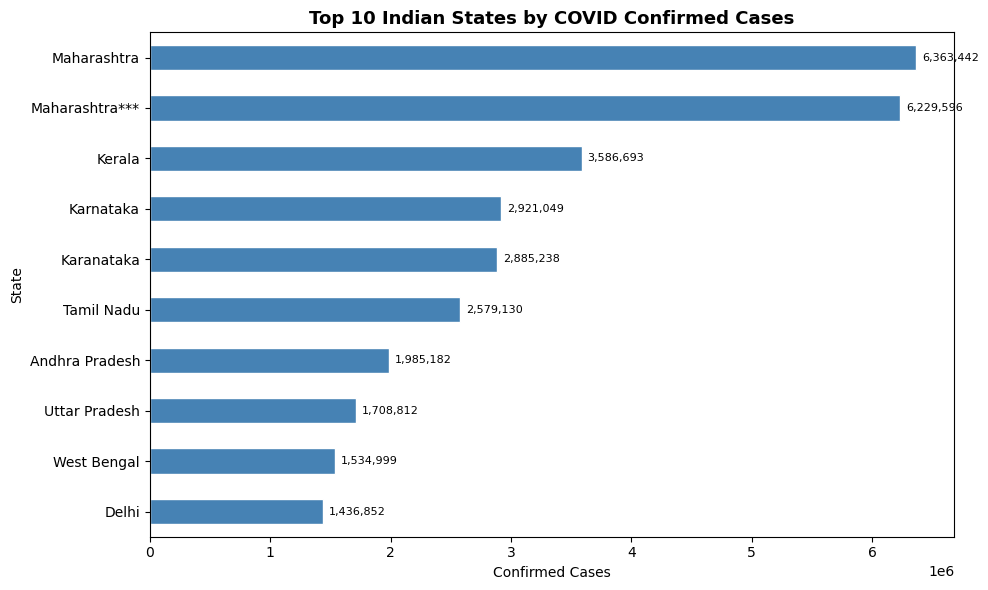

Chart saved!


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

state_cases.sort_values().plot(
    kind="barh",
    ax=ax,
    color="steelblue",
    edgecolor="white"
)

ax.set_title("Top 10 Indian States by COVID Confirmed Cases", fontsize=13, fontweight='bold')
ax.set_xlabel("Confirmed Cases")
ax.set_ylabel("State")

# Add value labels on bars
for i, v in enumerate(state_cases.sort_values()):
    ax.text(v + 50000, i, f'{v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig("covid_top10_states.png", dpi=100, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Insight 
The bar chart highlight the top 10 states with the highest COVID-19 cases, with the leading state showing a significantly higher number compared to others. This indicates that the impact of the pandemic was concentrated in a few highly affected regions, while othe states reported comparatively lower case counts.

## Death rate vs Recovery rate pie chart

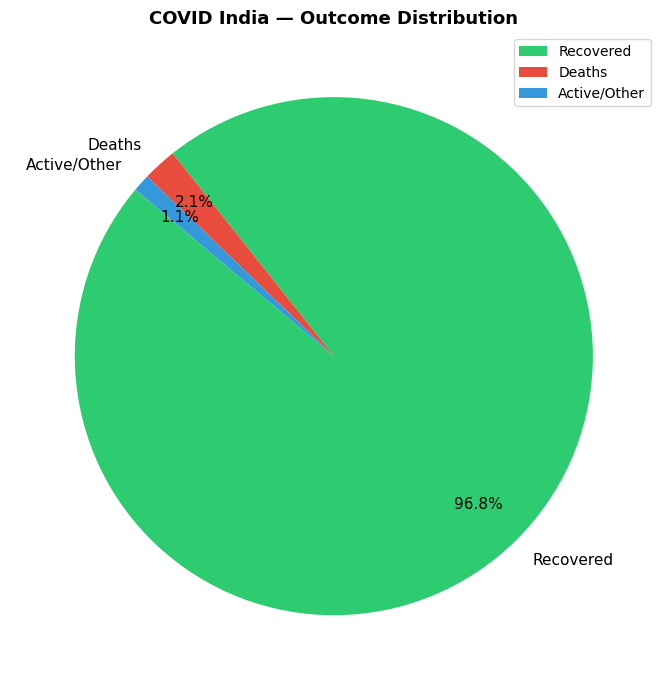

Pie chart saved!


In [11]:
fig, ax = plt.subplots(figsize=(7, 7))

sizes = [recovery_rate, death_rate, 100 - recovery_rate - death_rate]
labels = ['Recovered', 'Deaths', 'Active/Other']
colors_pie = ['#2ecc71', '#e74c3c', '#3498db']
explode = (0, 0, 0)   # explode only deaths for focus

ax.pie(
    sizes,
    labels=labels,
    colors=colors_pie,
    explode=explode,
    autopct='%1.1f%%',
    startangle=140,              # better angle
    pctdistance=0.8,             # move % inside nicely
    labeldistance=1.1,           # labels outside properly
    textprops={'fontsize': 11}
)

ax.set_title("COVID India — Outcome Distribution", fontsize=13, fontweight='bold')

plt.legend(labels, loc="upper right")   # ✅ clear legend added
plt.tight_layout()
plt.savefig("covid_outcomes_pie.png", dpi=100, bbox_inches='tight')
plt.show()

print("Pie chart saved!")

### Insight
The pie chart illustrates the distribution of COVID-19 outcomes, where the recovery rate (96.8%) is significantly higher than the death rate (2.11%) and active cases. This suggests that the majority of patients recovered successfully, indicating a strong recovery trend and effective healthcare management during the pandemic.

## Daily new cases trend

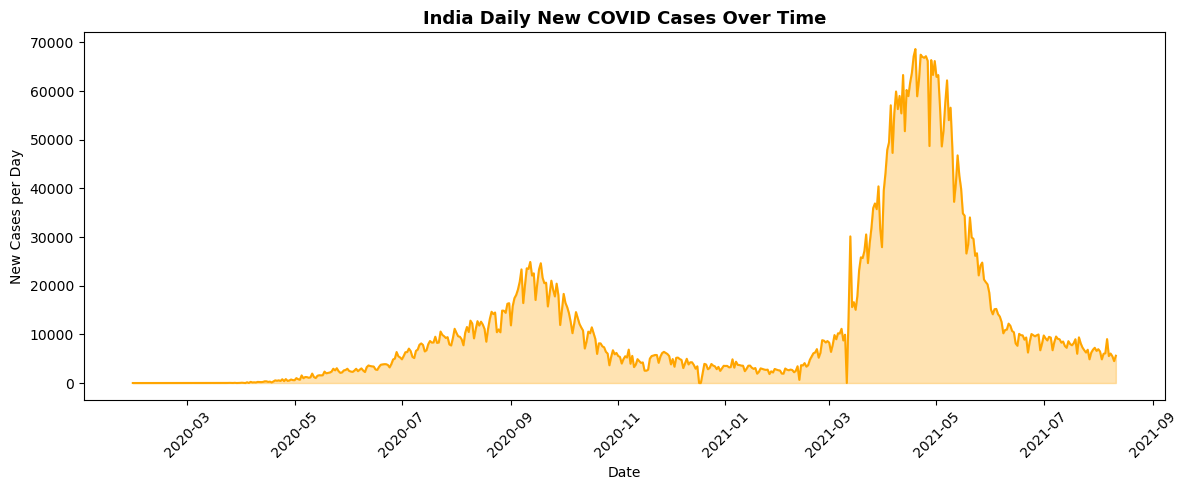

Trend chart saved!


In [12]:
# Convert date column
if 'Date' in covid.columns:
    covid['Date'] = pd.to_datetime(covid['Date'])
    
    # Get India total per date
    india_daily = covid.groupby('Date')['Confirmed'].max().reset_index()
    india_daily['New_Cases'] = india_daily['Confirmed'].diff().fillna(0)
    india_daily = india_daily[india_daily['New_Cases'] >= 0]
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(india_daily['Date'], india_daily['New_Cases'],
            color='orange', linewidth=1.5)
    ax.fill_between(india_daily['Date'], india_daily['New_Cases'],
                    alpha=0.3, color='orange')
    ax.set_title("India Daily New COVID Cases Over Time", fontsize=13, fontweight='bold')
    ax.set_xlabel("Date")
    ax.set_ylabel("New Cases per Day")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("covid_daily_trend.png", dpi=100, bbox_inches='tight')
    plt.show()
    print("Trend chart saved!")
else:
    print("No Date column found — skipping trend chart")

### Insight
The trend chart illustrates the daily new COVID-19 cases in India over time, showing noticeable fluctuations with periods of rapid increase followed by declines. This pattern suggests multiple waves of infection, indicating how the spread of the virus varied across different time periods.

## Key findings

In [13]:
print("=" * 50)
print("MY COVID INDIA EDA — KEY FINDINGS")
print("=" * 50)
print(f"1. Total confirmed cases in India: {total_confirmed:,}")
print(f"2. Recovery rate: {recovery_rate}% — most people recovered")
print(f"3. Death rate: {death_rate}% — relatively low")
print(f"4. Most affected state: {state_cases.index[0]}")
print(f"5. Least affected (top 10): {state_cases.index[-1]}")
print()
print("This is real data science — loading, cleaning,")
print("analysing, and drawing conclusions from real data.")
print("=" * 50)

MY COVID INDIA EDA — KEY FINDINGS
1. Total confirmed cases in India: 6,363,442
2. Recovery rate: 96.8% — most people recovered
3. Death rate: 2.11% — relatively low
4. Most affected state: Maharashtra
5. Least affected (top 10): Delhi

This is real data science — loading, cleaning,
analysing, and drawing conclusions from real data.
